# Direct integration of `MCube` and `RCTD` on the human CRC datasets

In [1]:
set.seed(20250626)
library(Matrix)
library(spacexr)
library(MCube)
library(ggplot2)

In [2]:
RESULT_PATH <- "/import/home/share/zw/pql/results/CRC"

## Visium dataset

### Cell type deconvolution results from `RCTD`

In [3]:
myRCTD <- readRDS(file.path(RESULT_PATH, "Visium", "myRCTD.rds"))

### Integration of `MCube` and `RCTD` using one line of code

In [4]:
mcube_object <- mcubeRCTD(myRCTD, RCTD_mode = "full", num_workers = 36, num_threads = 1, shared_memory = TRUE)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.1 and celltype_threshold = 100.

mcubeFilterCellTypes: Cell type(s) CAF, Goblet, Tumor III, vSM pass the threshold.

Cell type(s) Adipocyte, CD4 T cell, CD8 Cytotoxic T cell, Endothelial, Enteric Glial, Enterocyte, Epithelial, Fibroblast, Lymphatic Endothelial, Macrophage, Mast, Mature B, mRegDC, Myofibroblast, Neuroendocrine, Neutrophil, pDC, Pericytes, Plasma, Proliferating Immune II, QC_Filtered, SM Stress Response, Smooth Muscle, Tuft, Tumor I, Tumor II, Tumor V, Unknown III (SM) has/have less than the minimum celltype_threshold = 100 with proportion_threshold = 0.1.
To include the above cell type(s), please reduce celltype_threshold or proportion_threshold.

Cell type(s) CAF, Goblet, Tumor III, vSM will be analyzed.

Filter out lowly-expressed genes with gene_threshold = 5e-05.

mcubeFilte

### Visiualization

#### Cell type proportions

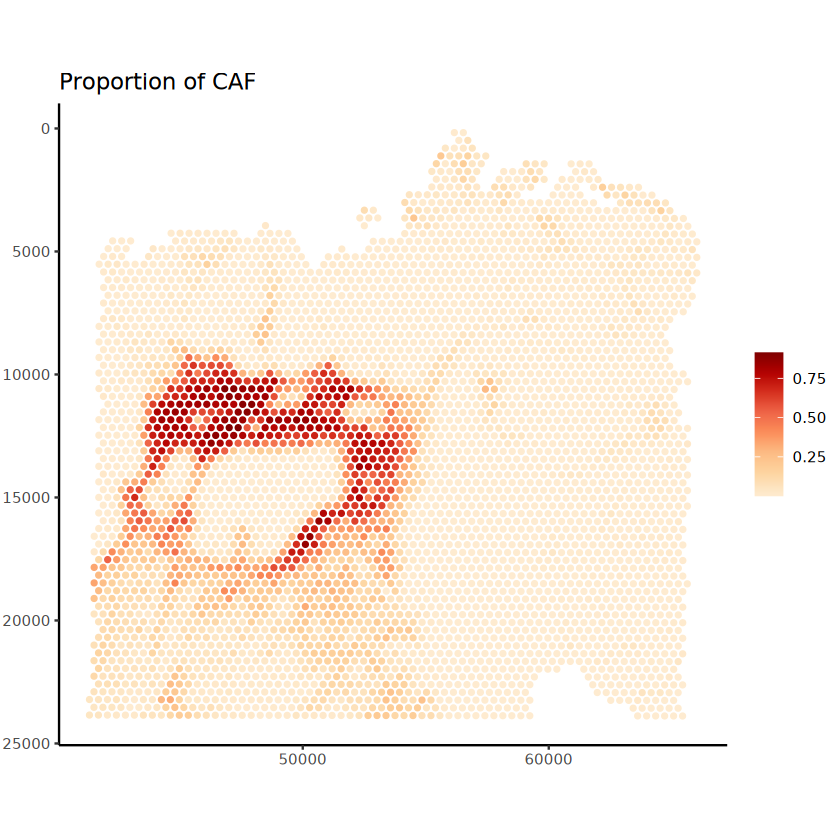

In [5]:
celltype <- "CAF"
mcubePlotPropCellType(mcube_object@proportions, mcube_object@coordinates, celltype)

In [6]:
head(mcubeGetSigGenes(mcube_object@pvalues)[[celltype]])

mcubeGetSigGenes: Set adjust_method as BH and alpha as 0.05.



,pvalue,adjusted_pvalue
,<dbl>,<dbl>
COL11A1,9.363617e-187,2.278168e-183
IGFBP3,3.241316e-165,3.943061e-162
TIMP1,8.404488e-162,6.816040e-159
C3,3.820964e-160,2.324101e-157
MGP,9.545114e-160,4.644653e-157
TIMP3,2.639377e-159,1.070267e-156


#### Overall gene expression

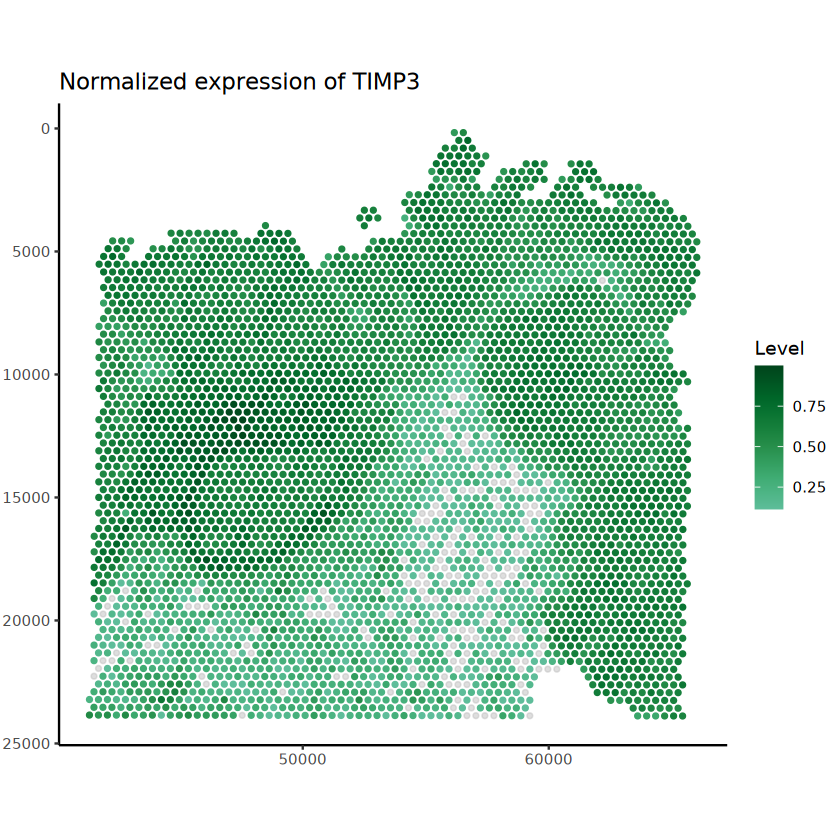

In [7]:
gene <- "TIMP3"
mcubePlotExpr(mcube_object@counts, mcube_object@coordinates, gene, background = TRUE)

#### Gene expression variations within a specific cell type

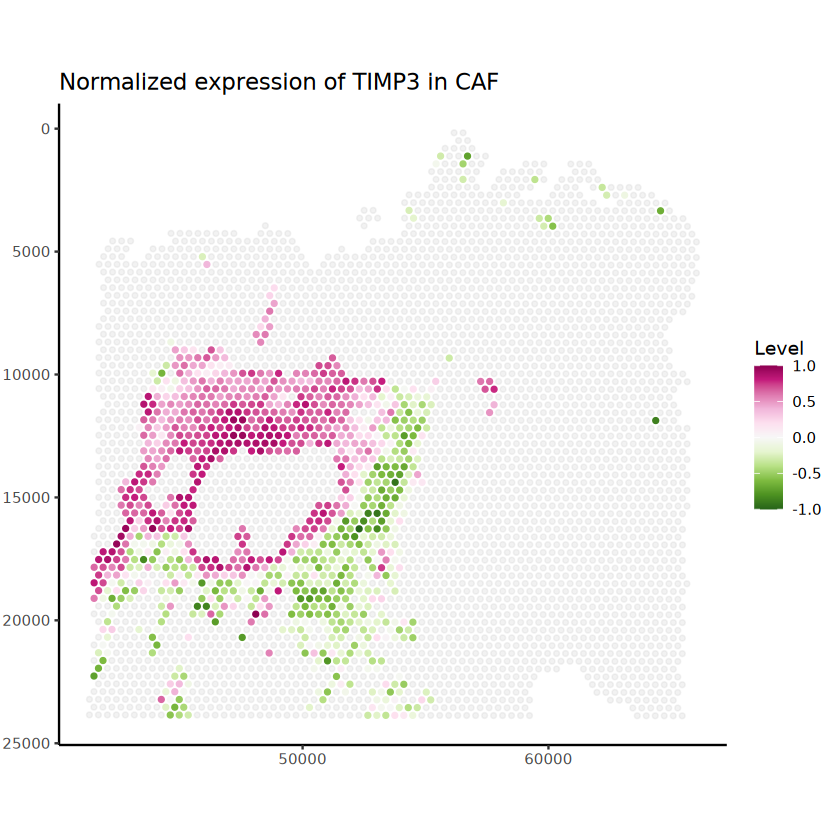

In [8]:
mcubePlotExprCellType(mcube_object, celltype, gene, background = TRUE)

## Xenium dataset

### Cell type deconvolution results from `RCTD`

In [9]:
myRCTD <- readRDS(file.path(RESULT_PATH, "Xenium", "myRCTD.rds"))

### Integration of `MCube` and `RCTD` using one line of code

In [10]:
mcube_list <- mcubeRCTD(myRCTD, RCTD_mode = "doublet", num_workers = 36, num_threads = 1, shared_memory = TRUE)

The batch_id is not provided!
All spots are assumed to be from the same batch and share the same gene platform effects.

Select high-abundance cell types to analyze with proportion_threshold = 0.01 and celltype_threshold = 100.

mcubeFilterCellTypes: Cell type(s) CAF, CD4 T cell, Macrophage, Myofibroblast, Pericytes, Plasma, Smooth Muscle, Tumor III, Unknown III (SM) pass the threshold.

Cell type(s) CAF will be analyzed.

Filter out lowly-expressed genes with gene_threshold = 5e-05.

mcubeFilterGenes: 364 genes pass the threshold.

The platform effects are not provided and need to be estimated from data!

Select highly-expressed genes to analyze for each specific cell type with reference_threshold = 0.5.

mcubeFilterGenesCellType: Select 77 genes to analyze for CAF.

Preprocessed data description: 5000 spots and 32 cell types in total. 5000 spots, 77 genes, and 1 cell type(s) to analyze.

Number of physical cores: 72.

Number of workers: 36.

Number of thread(s) on BLAS per worker: 1.

### Visiualization

In [11]:
celltype <- "CAF"
mcube_object <- mcube_list[[celltype]]

#### Cell type proportions

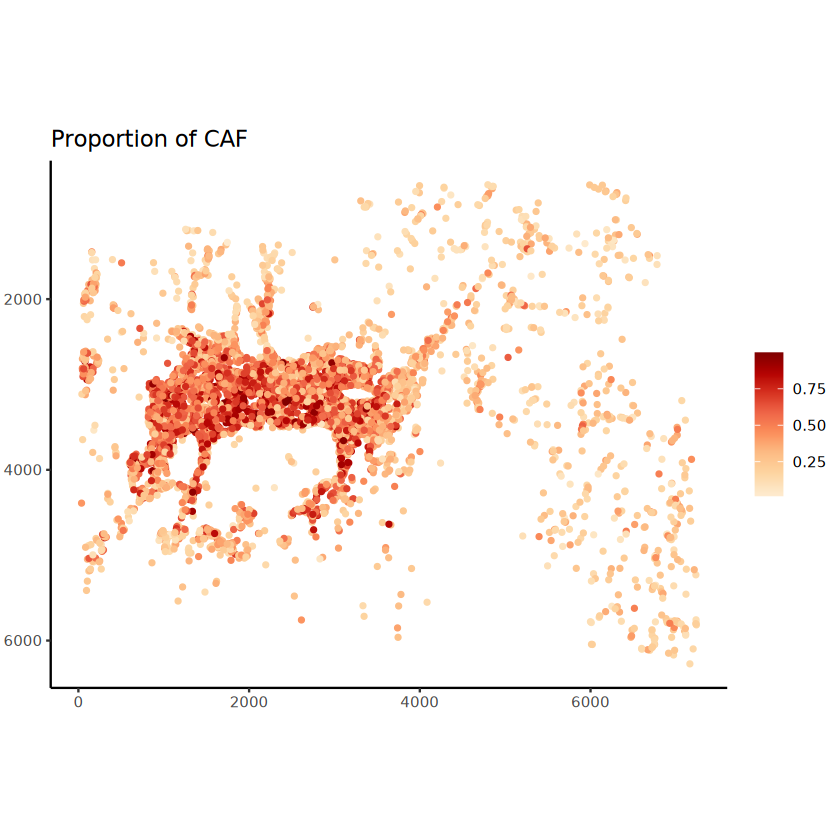

In [12]:
mcubePlotPropCellType(mcube_object@proportions, mcube_object@coordinates, celltype)

In [13]:
gene <- "TIMP3"
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TIMP3,1.945247e-49,2.147182e-176,2.382048e-198,1.406299e-06,2.517969e-08,2.382048e-198


#### Overall gene expression

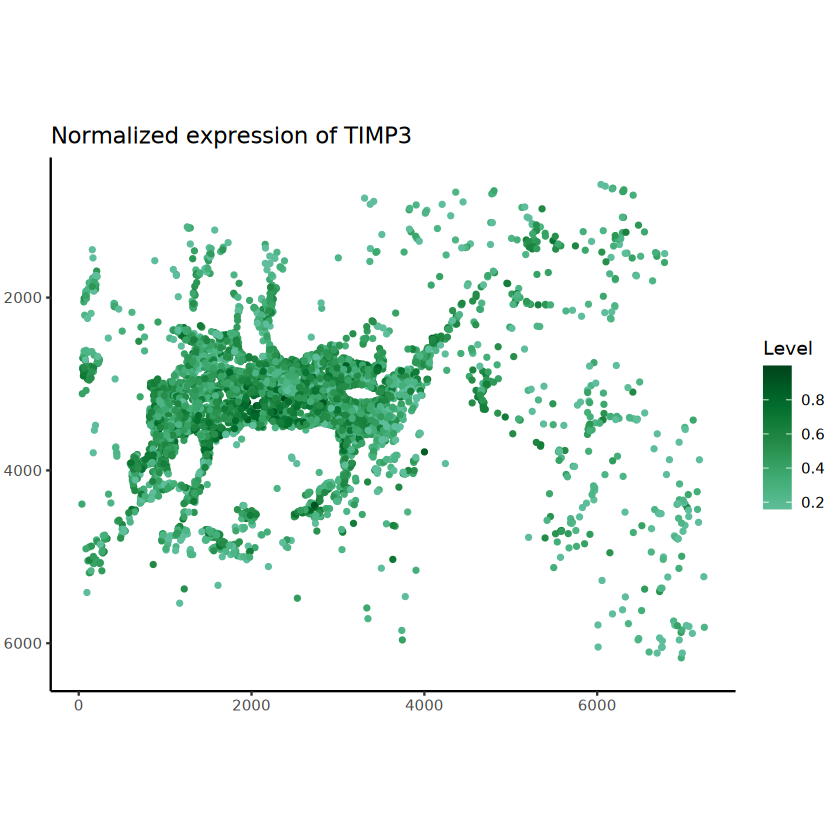

In [14]:
mcubePlotExpr(mcube_object@counts, mcube_object@coordinates, gene)

#### Gene expression variations within a specific cell type

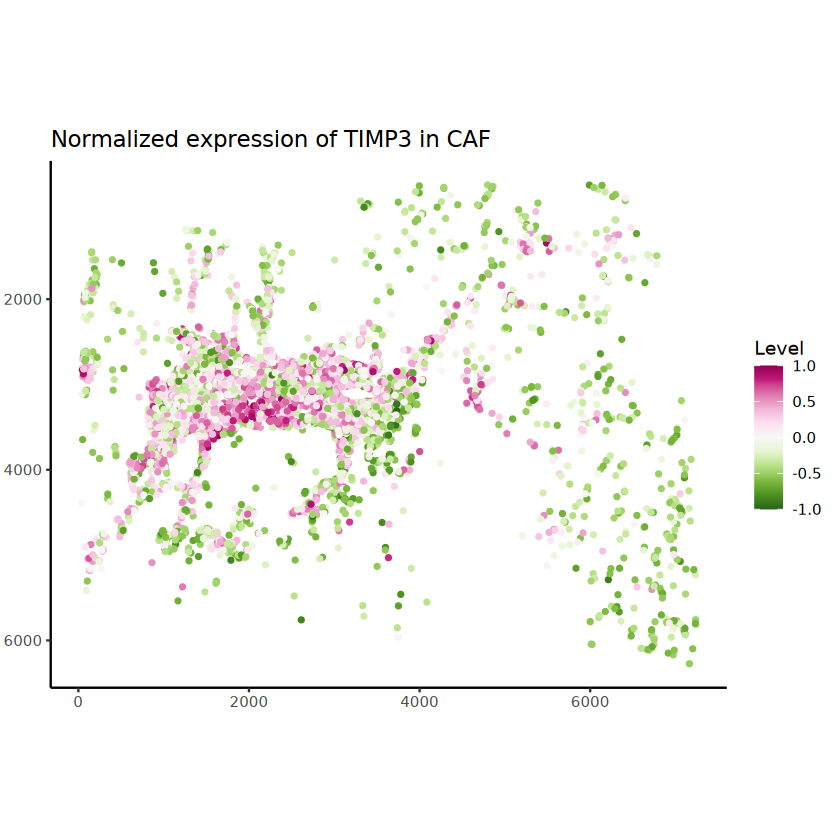

In [15]:
mcubePlotExprCellType(mcube_object, celltype, gene)